# **TP 2 : Transformée de Fourier et fonctions périodiques**

Le but de ce TP est d'illustrer les différentes notions introduites dans le chapitre 6 'Transformée de Fourier et fonctions périodiques' du cours Analyse de Fourier II.

On rappelle la définition de la fonction porte centrée en 0 et de largeur 1 (porte unité) : 
$$\Pi\left(t\right) =
\begin{cases}
    1 & \text{si } |t| \leq \displaystyle\frac{1}{2}, \\
    0 & \text{sinon. }
\end{cases}
$$

<span style="color:orange; font-size:larger;">⚠️ Attention:</span>
si vous utilisez la fonction `np.sinc()` préprogrammée, bien faire attention à la normalisation (utiliser l'aide).

## **Partie I : représentation de $\Pi_{1/2}(t)=\Pi(2t)$ et de sa transformée de Fourier**


On considère la fonction $\Pi_{1/2}(t)=\Pi(2t)$ le porte centrée en 0 et de largeur 1/2.

#### 1) a) Codez une fonction qui dépend de $t$ qui renvoie la valeur de $\Pi_{1/2}(t)$. La fonction doit pouvoir être évaluer sur des vecteurs (ne pas utiliser d'instruction conditionnée `if`). 

In [138]:
import numpy as np
import matplotlib.pyplot as plt

def Pi2(t):
    return (t>=(-1/4))*(t<=(1/4))


#### b) Représentez la fonction $\Pi_{1/2} : t\mapsto \Pi(2t)$ sur l'intervalle $[-4,4]$.

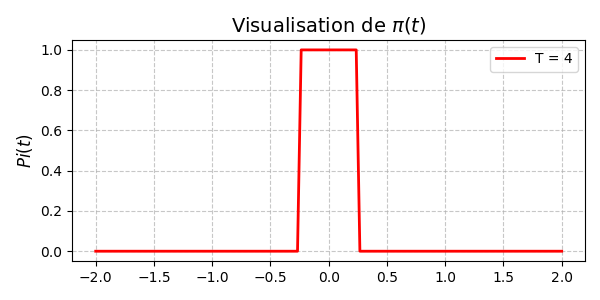

In [139]:
plt.clf();

#Paramètres
T=4
N=2**7
t = np.linspace(-T/2, T/2, N)

#tracé du graphique
plt.figure(figsize=(6, 3))
plt.plot(t, Pi2(t), 'r', linewidth=2, label=f'T = {T}')

#Personnalisation du graphique
plt.title(r'Visualisation de $\pi({t})$', fontsize=14)
plt.ylabel(r'$Pi(t)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

#Ajustement de l'espacement et affichage
plt.tight_layout()
plt.show()

In [ ]:
On retrouve bien une porte.

#### 2) a) Calculez la transformée de Fourier de $\Pi_{1/2}$ en utilisant l'algorithme de `fft` puis représentez graphiquement son module. 
#### b) Sur le même graphique, ajoutez le graphique du module de la transformée de Fourier exacte de $\Pi_{1/2}$ obtenue par calcul.

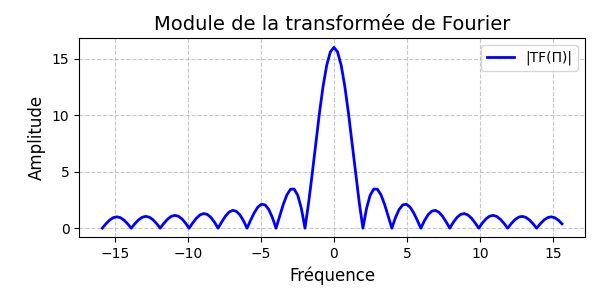

In [140]:
plt.clf();

#2)a)
# Paramètres
dt = t[1] - t[0]

# Signal
x = Pi2(t)

# FFT
X = np.fft.fft(x)
X = np.fft.fftshift(X)  # recentrage

# Axe fréquentiel
f = np.fft.fftfreq(N, d=dt)
f = np.fft.fftshift(f)

# Module
module = np.abs(X)

# Tracé
plt.figure(figsize=(6,3))
plt.plot(f, module, 'b', linewidth=2, label='|TF(Π)|')

plt.title("Module de la transformée de Fourier", fontsize=14)
plt.xlabel("Fréquence", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

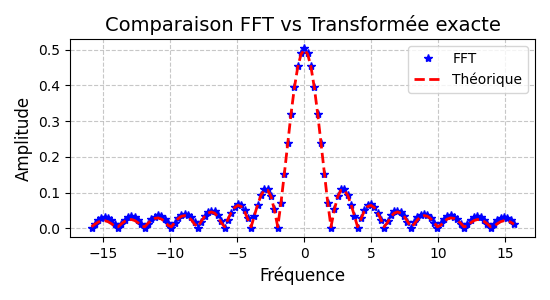

In [141]:
plt.clf();

#2)b)
dt = t[1] - t[0]

# Signal
x = Pi2(t)

# FFT (numérique)
X = np.fft.fftshift(np.fft.fft(x)) * dt
f = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
module_fft = np.abs(X)

# Transformée exacte
module_theorique = 0.5 * np.abs(np.sinc(f / 2))

# Tracé
plt.figure(figsize=(5.5,3))
plt.plot(f, module_fft, 'b*', linewidth=2, label='FFT')
plt.plot(f, module_theorique, 'r--', linewidth=2, label='Théorique')

plt.title("Comparaison FFT vs Transformée exacte", fontsize=14)
plt.xlabel("Fréquence", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
On peut voir que la FFT calculée est proche de la transformée exacte.

#### 3) Tracez l'erreur entre la transformée de Fourier obtenue par `fft` et la transformée de Fourier exacte. Que constatez-vous ?

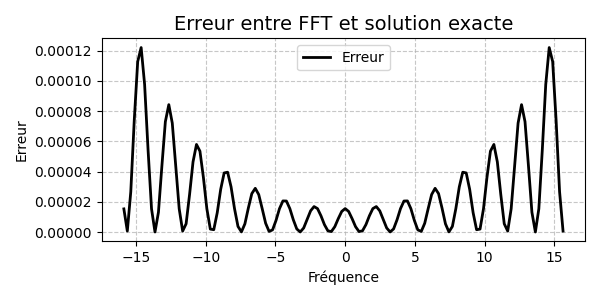

In [142]:
plt.clf();

# Signal
x = Pi2(t)

# FFT
X = np.fft.fftshift(np.fft.fft(x)) * dt
f = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
module_fft = np.abs(X)

# Théorique
module_theorique = 0.5 * np.abs(np.sinc(f / 2))

erreur = (np.abs(module_fft - module_theorique))**2

plt.figure(figsize=(6,3))
plt.plot(f, erreur, 'k', linewidth=2, label='Erreur')

plt.title("Erreur entre FFT et solution exacte", fontsize=14)
plt.xlabel("Fréquence")
plt.ylabel("Erreur")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

L’erreur est globalement faible mais augmente aux hautes fréquences. Cela est dû à la discrétisation du signal et au nombre fini d’échantillons utilisés dans la FFT. Une meilleure précision pourrait être obtenue en augmentant le nombre de points.

## **Partie II : périodisation de $\Pi_2$ et série de Fourier**

Les objectifs de cette partie sont :

        - illustrer le fait que la transformée de Fourier d'une fonction échantillonnée est périodique ;

        - illustrer le phénomène de repliement de spectre.


#### 4) Soit $g$ une fonction. On rappelle que $$g * \left(\sum_{n=-m}^{m} \delta(t - nT)\right) =\sum_{n=-m}^{m}g(t-nT) $$
#### Autrement dit, on obtient 2m+1 répliques de la fonction $g$, centrées en les entiers n pour $-m \leq n \leq m$.

#### Créez une fonction, nommée `g_replique`, qui prend en paramètres d'entrée :
   - $g$ une fonction ;
   - $T>0$ la période ;
   - $t$ un réel ou un vecteur ;
   - $m$  un entier ; 
#### et qui renvoie $$\sum_{n=-m}^{m}g(t-nT).$$
#### Nous utiliserons en particulier cette fonction pour représenter sur l'intervalle $[-Tm/2 , Tm/2]$  la fonction périodique de période T égale à g sur l'intervalle $[-T/2 , T/2]$.

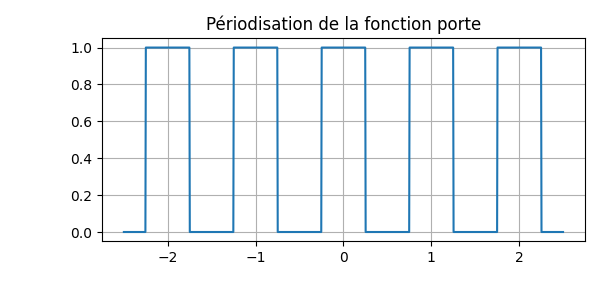

In [143]:
plt.clf();

def g_replique(g, T, t, m):
    t = np.array(t)
    y = np.zeros_like(t, dtype=float)
    
    for n in range(-m, m+1):
        y += g(t - n*T)
    
    return y


T = 1
m = 5
t = np.linspace(-T*m/2, T*m/2, 1000)

y = g_replique(Pi2, T, t, m)

plt.plot(t, y)
plt.title("Périodisation de la fonction porte")
plt.grid()
plt.show()

In [ ]:
On obtient donc bien une porte périodisée

#### 5)  a) Représentez, sur l'intervalle $[-7/2,7/2]$, la fonction périodique de période 1 et égale à $\Pi_{1/2}(t)$ sur l'intervalle $[-1/2,1/2]$.
#### On utilisera la fonction `g_replique` précedemment définie.

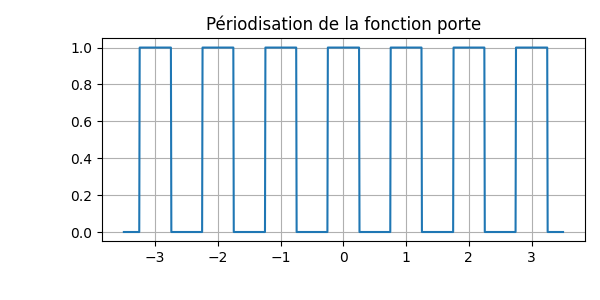

In [144]:
plt.clf();

T = 1
m = 7
t = np.linspace(-T*m/2, T*m/2, 1000)

y = g_replique(Pi2, T, t, m)

plt.xticks(np.arange(-4, 5, 1))  # de -4 à 4 par pas de 1
plt.plot(t, y)
plt.title("Périodisation de la fonction porte")
plt.grid()
plt.show()

#### 5) b) Représentez, sur l'intervalle $[-1,1]$, la fonction périodique de période 1/4 et égale à $\Pi_{1/2}(t)$ sur l'intervalle $[-1/2,1/2]$.
#### On utilisera la fonction `g_replique` précedemment définie.
#### Commentez le résultat obtenu.

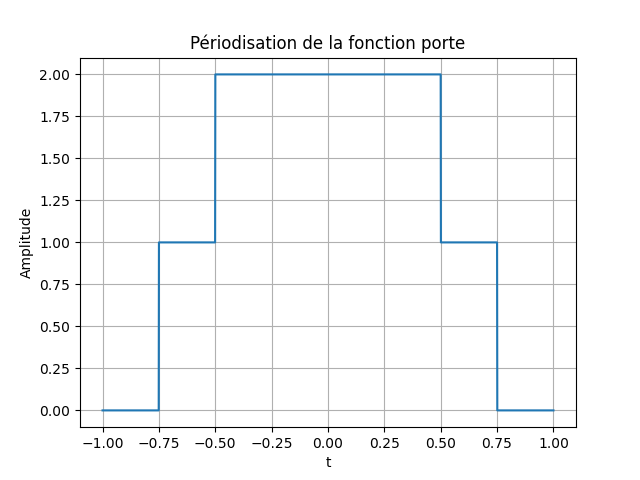

In [149]:
plt.clf();

# Suppose que g_replique est déjà défini

T = 0.25          # période
m = 2             # nombre de répétitions de la fonction sur l'intervalle
t = np.linspace(-1, 1, 2000)  # intervalle complet [-1,1]   

y = g_replique(Pi2, T, t, m)

plt.figure()
plt.plot(t, y)
plt.title("Périodisation de la fonction porte")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

On peut remarquer que l'amplitude augmente au centre car les portes se superposent au cause de la période trop petite.

#### 6) On appelle $g_{per}$ la fonction périodique de période 1 et égale à $\Pi_{1/2}(t)$ sur l'intervalle $[-1/2,1/2]$. Calulez $\hat{g}_{per}$, la transformée de Fourier de $g_{per}$. Quelle est la nature de $\hat{g}_{per}$ ?

$ \hat{gper}(f) $ = $\ \hat{\Pi}_{1/2}  \hat{Ш}_{1} (f)$ = $ \frac{1}{2} sinc ( \pi f)  \text{Ш}_{1} ( f) $

Elle est symétrique

#### 7) Représenter $\hat{g}_{per}$, la transformée de Fourier de $g_{per}$, sur l'intervalle $[-10,10]$.

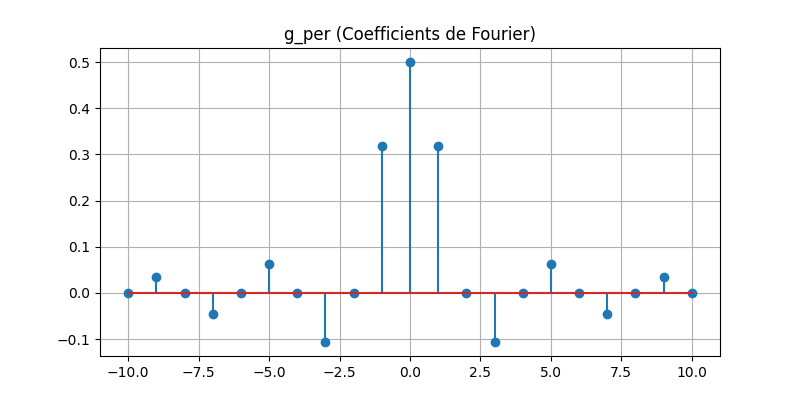

In [179]:
n = np.arange(-10, 11)
cn = 0.5 * np.sinc(n / 2)
plt.figure(figsize=(8, 4))
plt.stem(n, cn)
plt.title(r"g_per (Coefficients de Fourier)")
plt.grid(True)
plt.show()

In [ ]:
On remarque qu on a échatilloné un sinus cardinal.

#### 8) On s'intéresse au fonctionnement de `np.newaxis`.

#### `np.newaxis` est utilisé pour ajouter une nouvelle dimension à un tableau NumPy. En d'autres termes, il permet de transformer un tableau unidimensionnel en un tableau multidimensionnel.
#### L'objectif est généralement de modifier la forme (les dimensions) du tableau afin de faciliter des opérations vectorielles.

In [180]:
A = np.array([-3, -2, -1, 0, 1, 2, 3])
t = np.array([0, 0.5, 1])

print('A=',A)
print('A est une matrice de taille',np.shape(A))

print('t=',t)
print('t est une matrice de taille',np.shape(t))



A= [-3 -2 -1  0  1  2  3]
A est une matrice de taille (7,)
t= [0.  0.5 1. ]
t est une matrice de taille (3,)


#### On souhaite créer la matrice B de taille $3 \times 7$ définie par :
$$B(i,j)=A(j) \times t(i)$$ 

Est-il possible de faire A*t ? 

In [181]:
A*t

Traceback (most recent call last):
  File "<basthon-input-181-66f84774d60a>", line 1, in <module>
    A*t
    ~^~
ValueError: operands could not be broadcast together with shapes (7,) (3,) 


Non pas possible, il y a un problème de dimension.

#### Que fait la commande suivante ?

In [182]:
print(A[:, np.newaxis])
A[:, np.newaxis] * t


[[-3]
 [-2]
 [-1]
 [ 0]
 [ 1]
 [ 2]
 [ 3]]


array([[-0. , -1.5, -3. ],
       [-0. , -1. , -2. ],
       [-0. , -0.5, -1. ],
       [ 0. ,  0. ,  0. ],
       [ 0. ,  0.5,  1. ],
       [ 0. ,  1. ,  2. ],
       [ 0. ,  1.5,  3. ]])

On a multiplié t par chaque élément de la matrice A.

#### 9) a) Donner l'expression de la série de Fourier de la fonction $g_{per}$ en fonction de $\hat{\Pi}_{1/2}(n)$.

Puisque $g_{per}$ est une fonction périodique de période $T=1$, elle admet un développement en série de Fourier de la forme :
$$g_{per}(t) = \sum_{n=-\infty}^{+\infty} c_n e^{i 2\pi n t}$$

D'après le lien entre les coefficients de Fourier et la Transformée de Fourier du motif $\phi$ :
$$c_n = \frac{1}{T} \hat{\phi}\left(\frac{n}{T}\right)$$

Ici $T=1$ et $\phi = \Pi_{1/2}$, donc :
$$c_n = \hat{\Pi}_{1/2}(n)$$

L'expression de la série de Fourier est donc :
$$g_{per}(t) = \sum_{n=-\infty}^{+\infty} \hat{\Pi}_{1/2}(n) e^{i 2\pi n t} = \sum_{n=-\infty}^{+\infty} \frac{1}{2}\text{sinc}\left(\frac{n}{2}\right) e^{i 2\pi n t}$$

#### 9) b) Que représente $\sum_{n=-N}^{N} \hat{\Pi}_{1/2}(n) e^{2 i \pi n t}$ ? 
#### Ecrire une fonction, nommée *serie_Fourier*, qui prend en paramètres d'entrée : 
    - t un vecteur ;
    - N un entier ;
####  et qui renvoie $\sum_{n=-N}^{N} \hat{\Pi}_{1/2}(n) e^{2 i \pi n t}$.

#### On utilisera `np.newaxis` pour obtenir une fonction sans boucle for.

C'est l'expression de la série de Fourier mais entre -N et N et pas les infinis. Ce qui permet alors de l'utiliser dans le code

In [183]:
def serie_Fourier(t, N):
    n = np.arange(-N, N + 1)[:, np.newaxis]
    cn = 0.5 * np.sinc(n / 2)
    return np.sum(cn * np.exp(2j * np.pi * n * t), axis=0).real

#### 10) Tracez la série de Fourier de $g_{per}$ pour différentes valeurs de $N$ sur l'intervalle $[-1,1]$. Commentez le résultat obtenu.

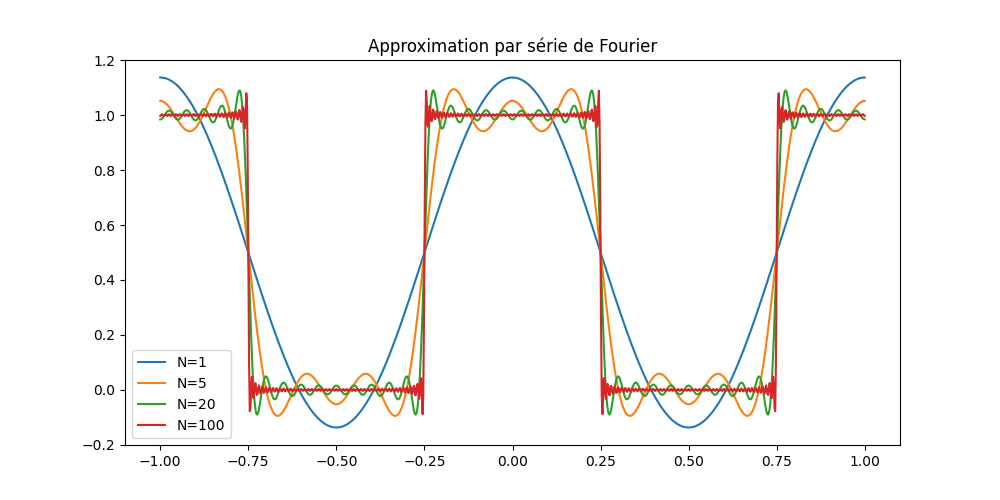

In [184]:
t_sf = np.linspace(-1, 1, 1000)
plt.figure(figsize=(10, 5))
for N in [1, 5, 20, 100]:
    plt.plot(t_sf, serie_Fourier(t_sf, N), label=f"N={N}")
plt.legend()
plt.title("Approximation par série de Fourier")
plt.show()

On voit bien un signal décomposer en plusieurs sinusoïde, ce qui est cohérent pour une série de Fourier.

## **Partie III : Transformée de Fourier d'une fonction échantillonnée** 

#### On considère la fonction  $\displaystyle s(t)= \frac{sin\left(\frac{\pi t}{ 2}\right)}{\pi t}$.

#### 11) Représentez la fonction $s$ ainsi que sa transformée de Fourier $\hat{s}$ côte à côte à l'aide de la commande `plt.subplots()`.

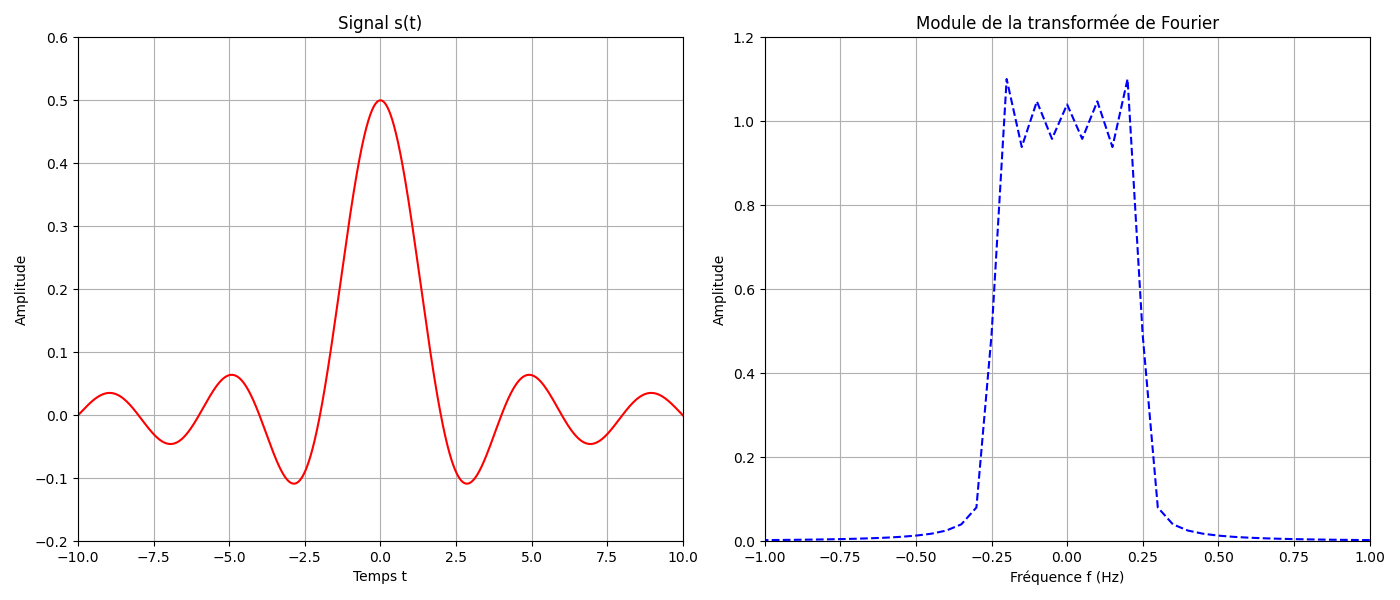

In [161]:
import numpy as np
import matplotlib.pyplot as plt

def s(t):
    y = np.sin(np.pi * t / 2) / (np.pi * t)
    y[np.isclose(t, 0)] = 0.5
    return y

t = np.linspace(-10, 10, 4096)
dt = t[1] - t[0]
N = len(t)
x = s(t)

X = np.fft.fftshift(np.fft.fft(x)) * dt
f = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
module_fft = np.abs(X)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Signal
axes[0].plot(t, x, 'r')
axes[0].set_title("Signal s(t)")
axes[0].set_xlabel("Temps t")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-0.2, 0.6)
axes[0].grid(True)

# FFT
axes[1].plot(f, module_fft, 'b--')
axes[1].set_title("Module de la transformée de Fourier")
axes[1].set_xlabel("Fréquence f (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(0, 1.2)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### 12) a) Quelle est la  fréquence de coupure de la fonction $s$ ?


La fréquence de coupure est d'environ 0,25 Hz

#### 12) b) Quel est le pas d'échantillonnage optimal ? 

Le pas d'échantillonage est 2

#### 12) c)  On note $s_{h}$ l'échantillonnage de la fonction $t \mapsto hs(t) $ avec un pas de $h$.  
#### Quelle est la nature de la transformée de Fourier de $s_{h}$ ?
#### Tracez la transformée de Fourier de $s_h$ pour différentes valeurs de $h$ : $h <h_{opt}$, $h =h_{opt}$ et $h >h_{opt}$. On utilisera la commande `plt.subplots()` pour représenter côte à côte la fonction échantillonnée et sa transformée de Fourier. On pourra utiliser la fonction `g_replique` précédemment programmée. 
#### Commentez le résultat obtenu.

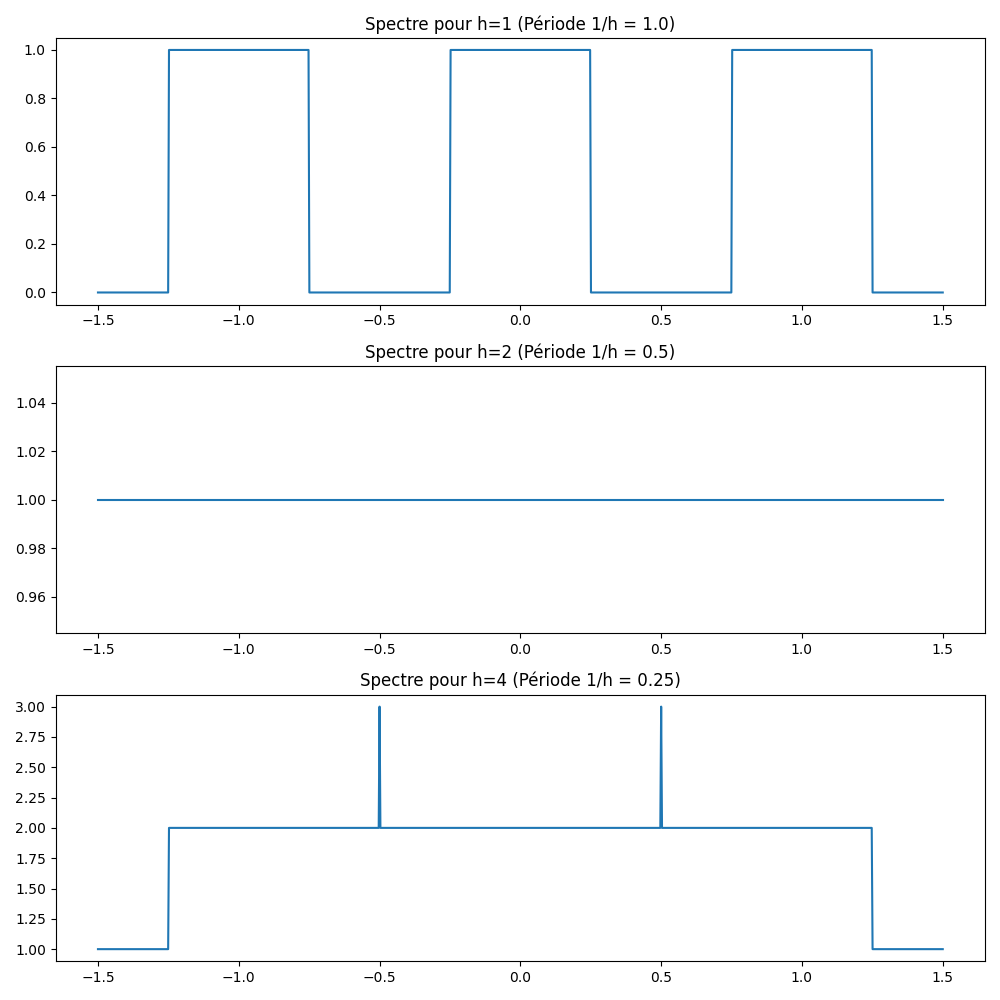

In [186]:
h_vals = [1, 2, 4]
f_ax = np.linspace(-1.5, 1.5, 1000)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
for i, h in enumerate(h_vals):
    spectre_h = g_replique(Pi2, 1/h, f_ax, 5)
    axes[i].plot(f_ax, spectre_h)
    axes[i].set_title(f"Spectre pour h={h} (Période 1/h = {1/h})")
plt.tight_layout()
plt.show()

## **Partie IV : Illustration du théorème de Shannon-Wittaker** (Bonus)

#### 13) Comment est définie la fonction préprogrammée  `np.sinc()` ?


In [187]:
help(np.sinc)

Help on _ArrayFunctionDispatcher in module numpy:

sinc(x)
    Return the normalized sinc function.

    The sinc function is equal to :math:`\sin(\pi x)/(\pi x)` for any argument
    :math:`x\ne 0`. ``sinc(0)`` takes the limit value 1, making ``sinc`` not
    only everywhere continuous but also infinitely differentiable.

    .. note::

        Note the normalization factor of ``pi`` used in the definition.
        This is the most commonly used definition in signal processing.
        Use ``sinc(x / np.pi)`` to obtain the unnormalized sinc function
        :math:`\sin(x)/x` that is more common in mathematics.

    Parameters
    ----------
    x : ndarray
        Array (possibly multi-dimensional) of values for which to calculate
        ``sinc(x)``.

    Returns
    -------
    out : ndarray
        ``sinc(x)``, which has the same shape as the input.

    Notes
    -----
    The name sinc is short for "sine cardinal" or "sinus cardinalis".

    The sinc function is used in various s

#### 14) Illustrez la reconstruction de $s$ obtenue à partir des échantillons grâce au théorème de Shannon-Wittakker pour différents pas d'échantillonnage $h$ sans utiliser de boucle `for`. Commentez le résultat obtenu.

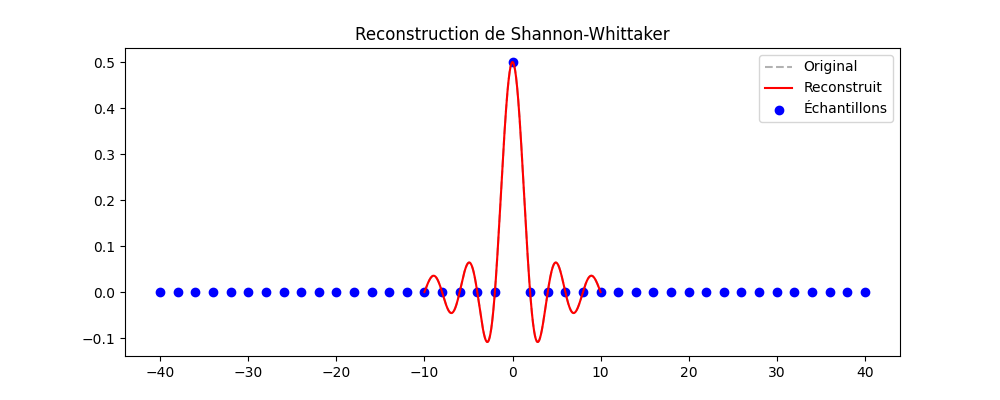

In [188]:
def reconstruct_shannon(t_eval, t_ech, h):
    val_ech = s(t_ech)
    diff = (t_eval[np.newaxis, :] - t_ech[:, np.newaxis]) / h
    return np.sum(val_ech[:, np.newaxis] * np.sinc(diff), axis=0)

t_fine = np.linspace(-10, 10, 1000)
h = 2.0 
t_ech = np.arange(-20, 21) * h

plt.figure(figsize=(10, 4))
plt.plot(t_fine, s(t_fine), 'k--', label="Original", alpha=0.3)
plt.plot(t_fine, reconstruct_shannon(t_fine, t_ech, h), 'r', label="Reconstruit")
plt.scatter(t_ech, s(t_ech), color='blue', label="Échantillons")
plt.legend()
plt.title("Reconstruction de Shannon-Whittaker")
plt.show()

L'illustration montre deux comportements distincts selon la valeur de $h$ :

1. **Si $h \le h_{opt}$ (ex: $h=1.5$ ou $h=2$) :** La reconstruction par la formule de Shannon-Whittaker (interpolation par sinus cardinaux) est **parfaite**. Le signal reconstruit se superpose exactement au signal original. Cela confirme que l'information contenue dans les échantillons discrets est suffisante pour retrouver tout le signal continu, car il n'y a pas eu de chevauchement des motifs dans le domaine fréquentiel (pas d'aliasing).

2. **Si $h > h_{opt}$ (ex: $h=3$) :** La reconstruction est **erronée**. Le signal reconstruit ne suit plus les oscillations rapides du signal original. C'est la conséquence directe du **repliement de spectre** : comme on a échantillonné trop lentement, les hautes fréquences du signal original ont été "confondues" avec des fréquences plus basses, et l'interpolation ne peut pas restaurer l'information perdue.